<a href="https://colab.research.google.com/github/minjun0072-glitch/-/blob/main/0403homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 필요한 라이브러리 불러오기
import requests
from bs4 import BeautifulSoup

# [1단계] requests로 웹페이지의 HTML 불러오기
url = "https://naver.com"
response = requests.get(url)

# 응답이 정상인지 확인 (200 OK 코드가 아니면 에러 발생시킴)
response.raise_for_status()

# html_text 변수에 가져온 HTML 텍스트를 저장
html_text = response.text
# print(html_text) # (확인용) 이 상태는 단순한 텍스트 덩어리야.

# --------------------------------------------------------

# [2단계] HTML 문서를 파싱하여 태그 구조 분석하기
# 'html.parser'는 파이썬에 내장된 기본 파서야.
soup = BeautifulSoup(html_text, 'html.parser')

# --------------------------------------------------------

# [3단계] 원하는 정보 추출하는 메서드 사용하기

# 방법 A: 단일 태그 찾기 - find()
# 문서에서 가장 처음 나오는 <title> 태그를 찾음
title_tag = soup.find('title')
print("1. 페이지 제목:", title_tag.text)

# 방법 B: 여러 태그 한 번에 찾기 - find_all()
# 문서에 있는 모든 <p> (문단) 태그를 리스트 형태로 가져옴
p_tags = soup.find_all('p')
for i, p in enumerate(p_tags):
    print(f"2. 문단 {i+1}:", p.text)

# 방법 C: CSS 선택자로 찾기 (가장 많이 쓰이고 유용함) - select_one() / select()
# 특정 태그, 클래스명, id 등을 직관적으로 지정해서 추출할 때 사용
# 아래는 <a> 태그(링크)를 찾는 예시
link_tag = soup.select_one('a')
if link_tag:
    print("3. 링크 텍스트:", link_tag.text)
    print("4. 링크 주소(href 속성값):", link_tag.get('href'))

1. 페이지 제목: NAVER
3. 링크 텍스트: 상단영역 바로가기
4. 링크 주소(href 속성값): #topAsideButton


All products의 100권의 책 제목을 불러온다.

In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

# 데이터를 담을 빈 리스트
books_data = []

print("데이터 수집을 시작합니다. (목표: 100권)\n")

# 한 페이지당 20권이므로, 1페이지부터 5페이지까지 반복 (총 100권)
for page in range(1, 6):
    # 페이지 번호가 바뀌는 URL 구조 활용
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)
    response.raise_for_status() # 오류 확인
    soup = BeautifulSoup(response.text, 'html.parser')

    # 해당 페이지의 모든 책 정보(20개)를 찾음
    books = soup.select('.product_pod')

    for book in books:
        # 책 제목은 <h3> 태그 안의 <a> 태그의 'title' 속성에 전체 이름이 있음
        title = book.select_one('h3 a').get('title')

        books_data.append({
            'Title': title
        })

    print(f"{page}페이지 수집 완료 (현재 누적: {len(books_data)}권)")
    time.sleep(0.5) # 서버 부하 방지를 위해 페이지를 넘길 때마다 0.5초 대기

# 리스트를 Pandas DataFrame으로 변환
df = pd.DataFrame(books_data)

print("\n✅ 수집 완료!")

# 결과 출력 (100개의 행이 정상적으로 들어갔는지 확인)
df

데이터 수집을 시작합니다. (목표: 100권)

1페이지 수집 완료 (현재 누적: 20권)
2페이지 수집 완료 (현재 누적: 40권)
3페이지 수집 완료 (현재 누적: 60권)
4페이지 수집 완료 (현재 누적: 80권)
5페이지 수집 완료 (현재 누적: 100권)

✅ 수집 완료!


,Title
0,A Light in the Attic
1,Tipping the Velvet
2,Soumission
3,Sharp Objects
4,Sapiens: A Brief History of Humankind
...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...
96,"Layered: Baking, Building, and Styling Spectac..."
97,Judo: Seven Steps to Black Belt (an Introducto...
98,Join


데이터 수집 중... (10개 카테고리, 각 10권씩)

✅ [결과 1] 카테고리별 가장 비싼 책 10권


,Category,Title,Price
0,Childrens,The White Cat and the Monk: A Retelling of the...,58.08
1,Classics,Candide,58.63
2,Fiction,The Murder That Never Was (Forensic Instincts #5),54.11
3,Historical Fiction,A Flight of Arrows (The Pathfinders #2),55.53
4,Mystery,The Past Never Ends,56.50
5,Philosophy,The Death of Humanity: and the Case for Life,58.11
6,Romance,Suddenly in Love (Lake Haven #1),55.99
7,Sequential Art,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29
8,Travel,A Year in Provence (Provence #1),56.88
9,Womens Fiction,I Had a Nice Time And Other Lies...: How to fi...,57.36



✅ [결과 2] 가격 데이터 정규성 검정 결과 (Shapiro-Wilk Test)
 - 검정 통계량 (Statistic): 0.9158
 - p-value: 8.4358e-06
 -> 결론: p-value가 유의수준 0.05보다 작으므로(거의 0에 수렴), 가격 데이터는 정규분포를 따르지 않습니다.


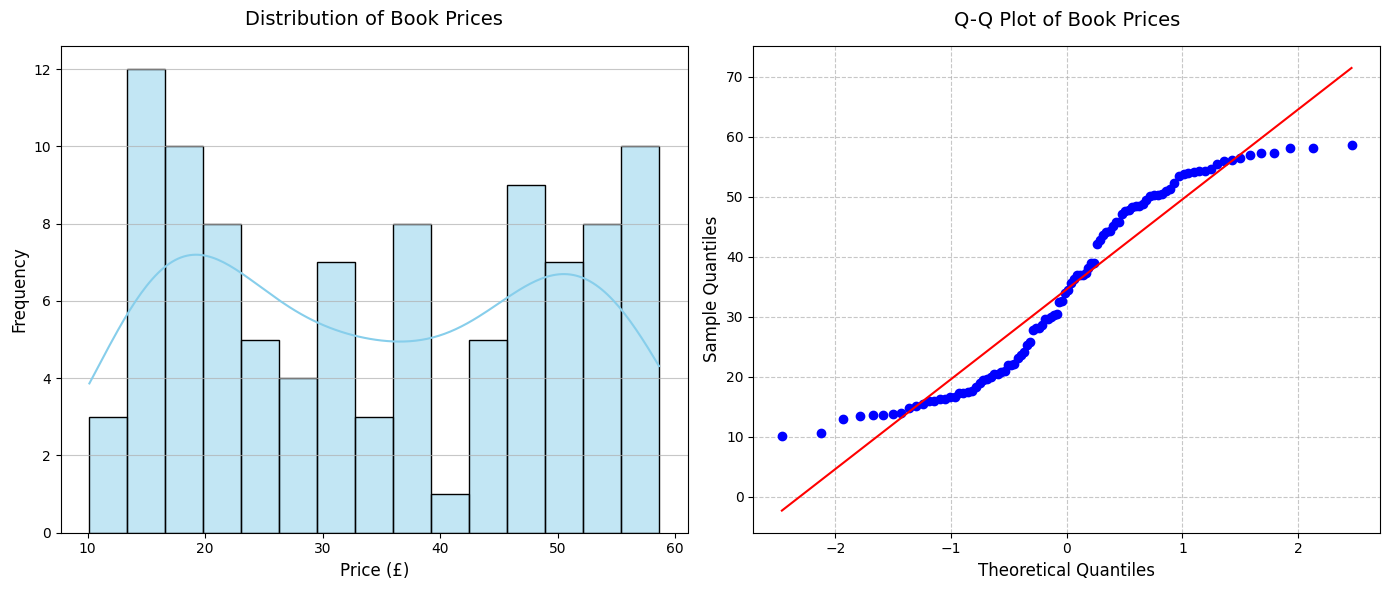

In [9]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------
# 1. 데이터 수집 (10개 카테고리 x 10권 = 100권)
# --------------------------------------------------------
base_url = "https://books.toscrape.com/"
response = requests.get(base_url)
soup = BeautifulSoup(response.text, 'html.parser')

categories = soup.select('.side_categories ul li ul li a')[:10]
all_books_data = []

print("데이터 수집 중... (10개 카테고리, 각 10권씩)\n")

for cat in categories:
    cat_name = cat.text.strip()
    cat_url = base_url + cat.get('href')

    cat_res = requests.get(cat_url)
    cat_soup = BeautifulSoup(cat_res.text, 'html.parser')

    books = cat_soup.select('.product_pod')[:10]

    for book in books:
        title = book.select_one('h3 a').get('title')
        price_text = book.select_one('.price_color').text
        price = float(re.sub(r'[^\d.]', '', price_text))

        all_books_data.append({
            'Category': cat_name,
            'Title': title,
            'Price': price
        })
    time.sleep(0.2)

df = pd.DataFrame(all_books_data)

# --------------------------------------------------------
# 2. 카테고리별 가장 비싼 책 1권씩 추출 (총 10권)
# --------------------------------------------------------
most_expensive_books = df.loc[df.groupby('Category')['Price'].idxmax()].reset_index(drop=True)
print("✅ [결과 1] 카테고리별 가장 비싼 책 10권")
display(most_expensive_books)

# --------------------------------------------------------
# 3. 정규분포 통계적 유의성 검정 (Shapiro-Wilk Test)
# --------------------------------------------------------
statistic, p_value = stats.shapiro(df['Price'])

print("\n✅ [결과 2] 가격 데이터 정규성 검정 결과 (Shapiro-Wilk Test)")
print(f" - 검정 통계량 (Statistic): {statistic:.4f}")
# p-value가 너무 작을 경우를 대비해 지수 표기법(e)으로 출력 (예: 1.23e-05)
print(f" - p-value: {p_value:.4e}")

alpha = 0.05
if p_value > alpha:
    print(f" -> 결론: p-value가 유의수준 {alpha}보다 크므로, 가격 데이터는 정규분포를 따른다고 볼 수 있습니다.")
else:
    print(f" -> 결론: p-value가 유의수준 {alpha}보다 작으므로(거의 0에 수렴), 가격 데이터는 정규분포를 따르지 않습니다.")

# --------------------------------------------------------
# 4. 데이터 분포 시각화 (히스토그램 & Q-Q Plot 동시 출력)
# --------------------------------------------------------
# 1행 2열의 그래프 공간(가로 14, 세로 6 크기) 생성
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# [왼쪽 그래프] 히스토그램
sns.histplot(df['Price'], kde=True, bins=15, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Book Prices', fontsize=14, pad=15)
axes[0].set_xlabel('Price (£)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(axis='y', alpha=0.7)

# [오른쪽 그래프] Q-Q Plot
# plot=axes[1]을 지정하여 오른쪽 공간에 그리도록 설정
stats.probplot(df['Price'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Book Prices', fontsize=14, pad=15)
axes[1].set_xlabel('Theoretical Quantiles', fontsize=12)
axes[1].set_ylabel('Sample Quantiles', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

# 두 그래프 간의 간격 자동 조절 및 출력
plt.tight_layout()
plt.show()